In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

In [3]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)

display(df.head())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

print("Features used:")
print(features)

Features used:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data scaling completed.")

Data scaling completed.


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

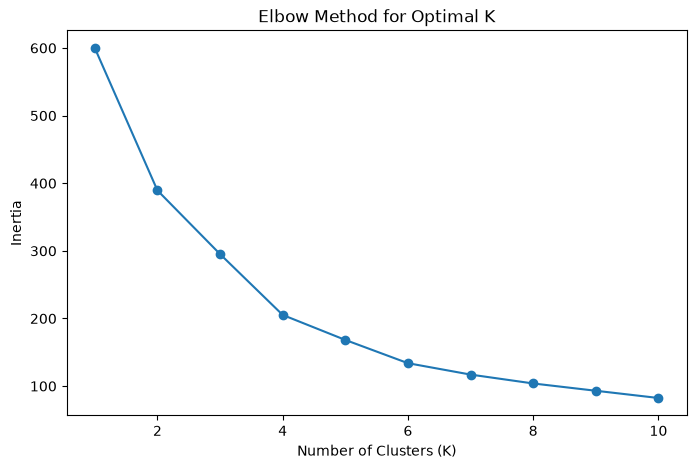

In [7]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("K-Means clustering completed.")

display(df.head())

K-Means clustering completed.


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


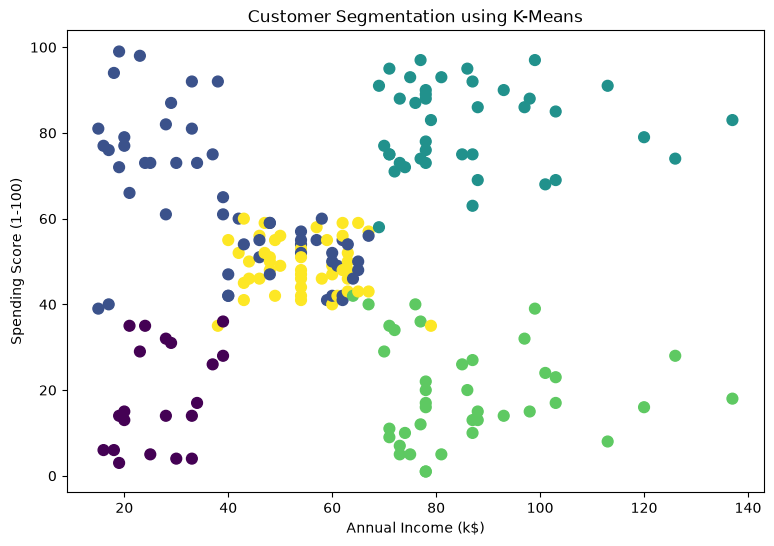

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

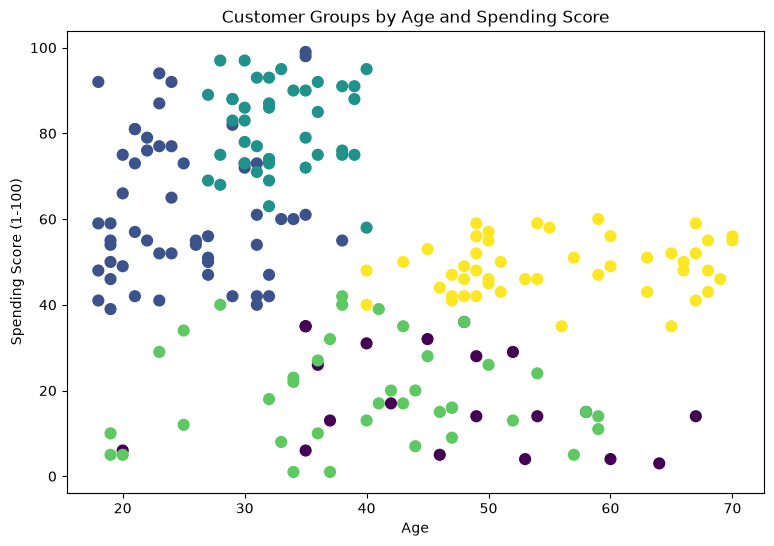

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df['Age'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=60
)

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Groups by Age and Spending Score")

plt.show()

In [11]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)

print("Average values for each customer cluster:")
display(cluster_summary)

Average values for each customer cluster:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.25,26.75,18.35
1,25.19,41.09,62.24
2,32.88,86.10,81.53
3,39.87,86.10,19.36
4,55.64,54.38,48.85


In [12]:
spending_means = df.groupby('Cluster')['Spending Score (1-100)'].mean()

sorted_clusters = spending_means.sort_values().index.tolist()

labels = {}

for i, cluster in enumerate(sorted_clusters):
    if i == 0:
        labels[cluster] = "Low Spenders"
    elif i == len(sorted_clusters) - 1:
        labels[cluster] = "High Spenders"
    else:
        labels[cluster] = "Medium Spenders"

df['Customer Segment'] = df['Cluster'].map(labels)

display(df.head(10))

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,1,Medium Spenders
1,2,Male,21,15,81,1,Medium Spenders
2,3,Female,20,16,6,0,Low Spenders
3,4,Female,23,16,77,1,Medium Spenders
4,5,Female,31,17,40,1,Medium Spenders
5,6,Female,22,17,76,1,Medium Spenders
6,7,Female,35,18,6,0,Low Spenders
7,8,Female,23,18,94,1,Medium Spenders
8,9,Male,64,19,3,0,Low Spenders
9,10,Female,30,19,72,1,Medium Spenders


Customer Segment Distribution:
Customer Segment
Medium Spenders    140
High Spenders       40
Low Spenders        20
Name: count, dtype: int64


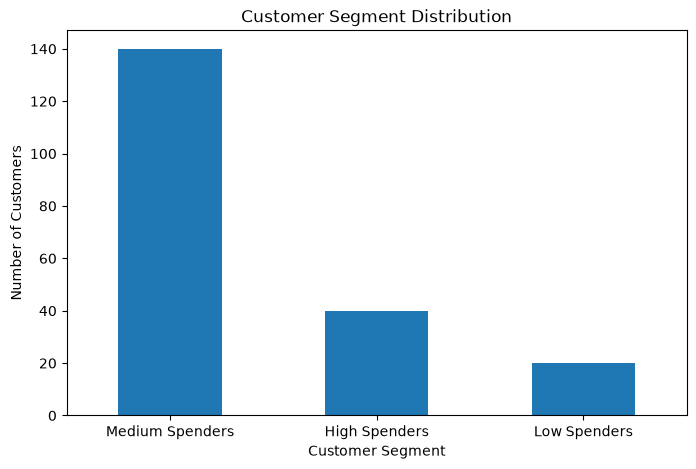

In [13]:
print("Customer Segment Distribution:")

print(df['Customer Segment'].value_counts())

plt.figure(figsize=(8, 5))

df['Customer Segment'].value_counts().plot(kind='bar')

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segment Distribution")

plt.xticks(rotation=0)

plt.show()

In [14]:
final_summary = df.groupby('Customer Segment')[features].mean().round(2)

display(final_summary)

,Age,Annual Income (k$),Spending Score (1-100)
Customer Segment,,,
High Spenders,32.88,86.10,81.53
Low Spenders,46.25,26.75,18.35
Medium Spenders,39.50,58.09,45.80


In [15]:
df.to_csv("Mall_Customers_Segmented.csv", index=False)

print("Segmented customer dataset saved successfully.")

Segmented customer dataset saved successfully.


In [16]:
joblib.dump(kmeans, "customer_segmentation_model.pkl")
joblib.dump(scaler, "customer_scaler.pkl")

print("K-Means model and scaler saved successfully.")

K-Means model and scaler saved successfully.


In [17]:
loaded_kmeans = joblib.load("customer_segmentation_model.pkl")
loaded_scaler = joblib.load("customer_scaler.pkl")

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.
